<a href="https://colab.research.google.com/github/keden49/Machine-learning-with-python-freecode-camp/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install TensorFlow for machine learning
!pip install tensorflow

In [21]:
# Upload Titanic dataset files from local machine to Colab
from google.colab import files
uploaded = files.upload()

# Rename test file to correct format
import os
os.rename('test.csv.xlsx', 'test.csv')
print(os.listdir()) #confirm if files uploaded


Saving train.csv to train.csv
Saving test.csv.xlsx to test.csv.xlsx
['.config', 'train.csv', 'test.csv', 'sample_data']


In [43]:
# Import necessary library
import tensorflow as tf
import numpy as np
import pandas as pd

In [11]:
#Allows for data visualization
import matplotlib.pyplot as plt


In [42]:
# Import TensorFlow feature column utilities
from tensorflow import feature_column as fc

# Import clear_output for cleaner notebook display
from IPython.display import clear_output

In [23]:
#Loading data
dftrain=pd.read_csv('train.csv')# training data
dfeval=pd.read_excel('test.csv')# testing data
y_train=dftrain.pop('Survived')# training labels
y_eval=dfeval.pop('Survived')# testing labels

In [24]:
# Display first few rows of the training data
dftrain.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,446,1,"Dodge, Master. Washington",male,4.0,0,2,33638,81.8583,A34,S
1,447,2,"Mellinger, Miss. Madeleine Violet",female,13.0,0,1,250644,19.5000,NaN,S
2,448,1,"Seward, Mr. Frederic Kimber",male,34.0,0,0,113794,26.5500,NaN,S
3,449,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,NaN,C
4,450,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5000,C104,S


In [25]:
# Display first few rows of surival coloumn
y_train.head()

,Survived
0,1
1,1
2,1
3,1
4,1


In [26]:
# Generate descriptive statistics for numeric columns
# Shows: count, mean, std, min, 25%, 50%, 75%, max percentiles
# Helps identify data distribution, missing values, and outliers
dftrain.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,446.000000,446.000000,357.000000,446.000000,446.000000,446.000000
mean,668.500000,2.273543,30.737871,0.457399,0.372197,32.032922
std,128.893367,0.854108,14.944219,1.015266,0.815875,50.017258
min,446.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,557.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,668.500000,3.000000,30.000000,0.000000,0.000000,14.479150
75%,779.750000,3.000000,39.000000,1.000000,0.000000,31.275000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

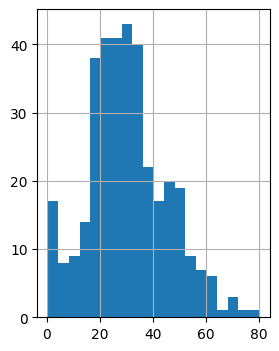

In [27]:
# Visualize Titanic passenger age distribution
# Bins=20: Groups ages into 20 ranges for detailed view
# Figsize=(3,4): Sets plot dimensions (3 inches wide, 4 inches tall)
dftrain.Age.hist(bins=20, figsize=(3,4))

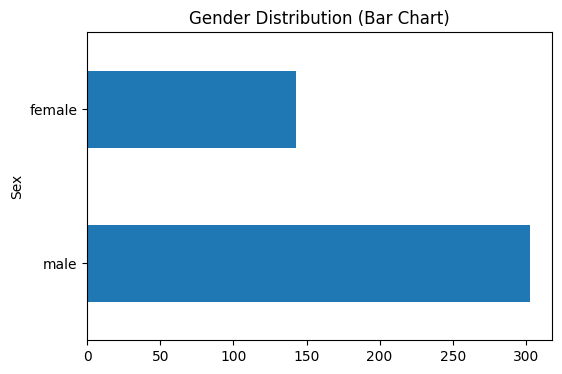

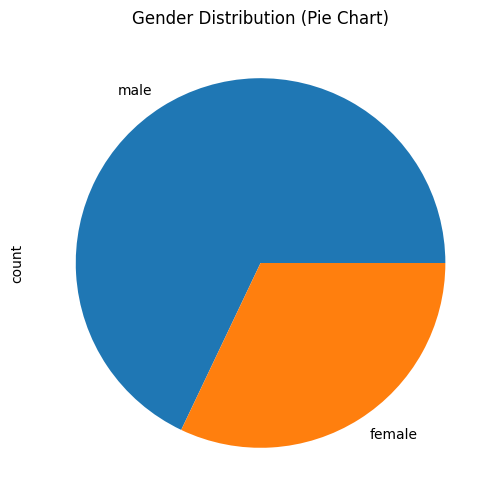

In [28]:
# Plots Titanic passenger gender distribution
# kind: Creates horizontal bar and pie
# men are more than women

plt.figure(figsize=(6, 4)) # Create a figure for the bar plot
dftrain.Sex.value_counts().plot(kind="barh")
plt.title('Gender Distribution (Bar Chart)')

plt.figure(figsize=(6, 6)) # Create a figure for the pie plot
dftrain.Sex.value_counts().plot(kind="pie")
plt.title('Gender Distribution (Pie Chart)')


plt.show() # Display the figures

<Axes: xlabel='Pclass'>

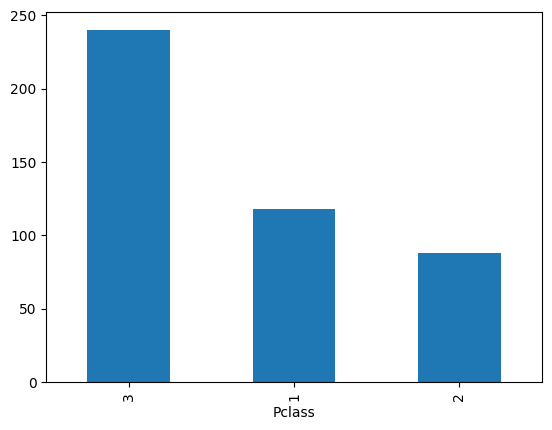

In [29]:
# Visualizing Class distribution
# value_counts(): Counts occurrences of each unique value(1,2,3)
# 3rd class passengers were more
dftrain['Pclass'].value_counts().plot(kind="bar")

<Axes: ylabel='Sex'>

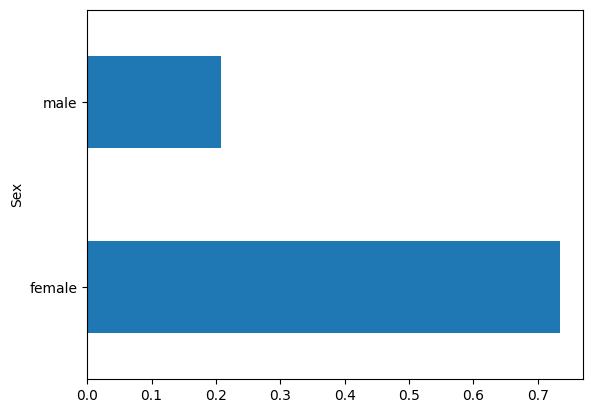

In [30]:
# visualize survival rate by gender:
#  pd.concat([dftrain, y_train], axis=1): Combine features with survival labels
#  axis = 1 enables side by side comparison
# .groupby('sex'): Group data by gender (male/female)
# .survived.mean(): Calculate average survival rate for each gender
# .plot(kind='barh'): Create horizontal bar chart
#  females had a higher chance of surviving

pd.concat([dftrain,y_train],axis=1).groupby('Sex').Survived.mean().plot(kind='barh')

In [31]:
#finding out the data type of the pandas dataframe
print(dftrain.dtypes)

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [61]:
# All panda objects need to be converted to numpy strings
# ensuring compatibility with tensorflow
#int64', 'float64', 'bool' are compatible with tensorflow directly
# NAN(missing values) are not compatible
# fillna fills this gaps
# .values gets column values in numpy array
# astype converts array () to numpy strings
CATEGORICAL_DTYPE = ['Sex', 'Embarked','Cabin','Name'] # object columns
NUMERIC_DTYPE = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']# compatible columns

def fix_categorical_types(df):
    for c in CATEGORICAL_DTYPE:  # loops through CATEGORICAL_DTYPE
        if c in df.columns: #checks if column exists
            df= df.copy() #creates a copy of the dataframe where changes will be modified
            if c == 'Embarked':
                df[c] = df[c].fillna('S')  # fills missing values with 'S'
            else:
                df[c] = df[c].fillna(df[c].mode()[0]) # Fills column with its mode (most common value)
            df[c] = df[c].values.astype('str') #converts from panda objects to numpy strings
    return df


In [62]:
# Filling missing values in numerical datatypes with median values
def fix_numeric_types(processed_df):

    for n in NUMERIC_DTYPE: #loops through NUMERIC_DTYPE
        if n in processed_df.columns:#checks if column exists
          processed_df[n] = processed_df[n].fillna(processed_df[n].median()) #fill missing values with the median value

    return processed_df

In [63]:
# fitting both training and testing data into function
# what function does
# fills missing values
# convert panda objects to numpy strings
dftrain_processed = fix_categorical_types(dftrain)
dftrain_processed = fix_numeric_types(dftrain_processed)# Pass the already processed DataFrame


dfeval_processed = fix_categorical_types(dfeval)
dfeval_processed= fix_numeric_types(dfeval_processed)# Pass the already processed DataFrame




In [64]:
# Before filling
print(dftrain['Cabin'].head())

0     A34
1     NaN
2     NaN
3     NaN
4    C104
Name: Cabin, dtype: object


In [38]:
#After filling gaps
print(dftrain_processed['Cabin'].head())

0     A34
1     B20
2     B20
3     B20
4    C104
Name: Cabin, dtype: object


In [68]:
#We are now mapping unique values in the categorical columns to interger values (1,0)
#This is to ensure compatibility with tensorflow
# feature columns are separated into 2 columns
#feature_column. # Module inside TensorFlow for feature handling
#.categorical_column_with_vocabulary_list, Maps each string value to an integer index
#Creates a lookup table - Builds a vocabulary-to-index mapping

CATEGORICAL_COLUMNS = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked','Cabin']#  List of column names containing discrete data
NUMERIC_COLUMNS = ['Age', 'Fare']# List of column names containing continuous data
feature_columns = []
for feature_name in CATEGORICAL_COLUMNS:
    vocabulary = dftrain[feature_name].unique() # Get unique values in feauture columns (example: Sex → ['male', 'female'])
    feature_columns.append(tf.feature_column.categorical_column_with_vocabulary_list(
        feature_name,  # column name
        vocabulary     # list of possible values

    ))



In [69]:
# Each numeric column represents a continuous feature that will be fed directly
# into the neural network without requiring categorical encoding

for feature_name in NUMERIC_COLUMNS:
   feature_columns.append(tf.feature_column.numeric_column(feature_name,dtype=tf.float32))


In [70]:
print(feature_columns)


[VocabularyListCategoricalColumn(key='Pclass', vocabulary_list=(np.int64(1), np.int64(2), np.int64(3)), dtype=tf.int64, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Sex', vocabulary_list=('male', 'female'), dtype=tf.string, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='SibSp', vocabulary_list=(np.int64(0), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(4), np.int64(8)), dtype=tf.int64, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Parch', vocabulary_list=(np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(3)), dtype=tf.int64, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Embarked', vocabulary_list=('S', 'C', 'Q', nan), dtype=tf.string, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Cabin', vocabulary_list=('A34', nan, 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'D', 'A14', 'B49', 'C93', 

In [73]:
#input function defines how dataset is batched $ shuffled at each epoch
#data_df = Features (dftrain)
#label_df = Labels (y_train)
#dict(data_df) = Converts DataFrame to dictionarionaries
#from_tensor_slices() slices loads of data into single rows
#eg of a dictonary column [{'Age':22, 'Sex':'male'...}, 0]
#.batch(batch_size) = Groups into chunks
#.repeat(num_epochs) = Repeats entire dataset
#Each epoch refines weights slightly in training


def make_input_fn(data_df, label_df, num_epochs=10, shuffle=True, batch_size=32):
  def input_function():  # enables new shuffle and batch creation at each epoch
    ds = tf.data.Dataset.from_tensor_slices((dict(data_df), label_df))  #convert panda dataframe to tensorflow dataset
    if shuffle:
      ds= ds.shuffle(1000)  # randomize order of data
      ds = ds.batch(batch_size).repeat(num_epochs) #splits the data into batches of 32 and repeats process for number of epochs
    return ds #inner function returns a new ds object shuffled and batched each time code runs
  return input_function  # outer fn return a function object for use


In [74]:
#Shuffling and Batching the dataset
#here we call on the input funtion which will return a dataset object which we will feed to the model
#epoch= 1 in evaluating stage as this is testing data
train_input_fn = make_input_fn(dftrain, y_train)
eval_input_fn = make_input_fn(dfeval, y_eval, num_epochs=1, shuffle=False)  # Keep order consistent

In [77]:
#Model Creation
#These are instructions for how to handle each type of data.
#Eg  "Age is a number, use it as-is"
#Eg "Sex is a category, convert male/female to one hot encoding"

linear_est = tf.estimator.LinearClassifier(feature_columns=feature_columns)

AttributeError: module 'tensorflow' has no attribute 'estimator'

In [76]:
#Training the Model
#"Minimizing loss = Learning in ML"
# We call the model on input_fn as its responsible for batching and shuffling our data

linear_est.train(train_input_fn) #training occurs and  # ← Weights learned here
pred_dict = list(linear_est.predict(eval_input_fn)) #returns the trained models predictions

NameError: name 'linear_est' is not defined

In [78]:
# Extract survival probabilities for each passenger
probs = pd.Series([pred['probabilities'][1] for pred in pred_dict])

NameError: name 'pred_dict' is not defined

In [79]:
# get model metrics/stats by making its own predictions,Compare prediction with actual labels,Calculates Loss and Accuracy
result = linear_est.evaluate(eval_input_fn)

NameError: name 'linear_est' is not defined

In [80]:
print(result[0]['probabilities'][1])#Accesses the first prediction in results list, Accesses the 'probabilities' key within that first prediction's dictionary, chances of surviving
print(resullt.loc[0]) #Accesses first row of DataFrame  with columns name side by side with value
clear_output() #clears console output
print(result['accuracy']) #the result variable is simply a dict of stats about our model

NameError: name 'result' is not defined